In [2]:
# 1. Install/import what we need
!pip -q install gdown scikit-learn
import gdown, zipfile, os
import glob, time, json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

DATA_ROOT = "/kaggle/working/iccad12_dataset/iccad-official"
IMG_SIZE = 96
BATCH_SIZE = 32
EPOCHS = 20
BASELINE_EPOCHS = 10   # paper trains its lightweight CNN for 5-10 epochs
BENCHMARKS = [1, 2, 3, 4, 5]

AUTOTUNE = tf.data.AUTOTUNE

In [3]:
# 0b. Checkpoint directory -- /kaggle/working/ persists automatically on Kaggle
# (especially with "Save & Run All / Commit"), no Drive mount needed here.
import os, json

CKPT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
RESULTS_CKPT = os.path.join(CKPT_DIR, "results.json")
TIMING_CKPT = os.path.join(CKPT_DIR, "timing_info.json")

In [4]:
# 2. Download the dataset from the shared Google Drive link
FILE_ID = "1jx7gDR92sqoIw2Nh4NGwwZwC-qNp2osd"
OUTPUT = "/kaggle/working/iccad12_dataset.zip"

gdown.download(id=FILE_ID, output=OUTPUT, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1jx7gDR92sqoIw2Nh4NGwwZwC-qNp2osd
From (redirected): https://drive.google.com/uc?id=1jx7gDR92sqoIw2Nh4NGwwZwC-qNp2osd&confirm=t&uuid=274bfad7-c7c5-455e-8a4a-9e3822bde24f
To: /kaggle/working/iccad12_dataset.zip
100%|██████████| 68.5M/68.5M [00:01<00:00, 51.1MB/s]


'/kaggle/working/iccad12_dataset.zip'

In [5]:
# Diagnostic + robust re-download
import subprocess
print(subprocess.run(["file", OUTPUT], capture_output=True, text=True).stdout)
print("Size (bytes):", os.path.getsize(OUTPUT))
with open(OUTPUT, "rb") as f:
    head = f.read(500)
print(head[:500])

if os.path.exists(OUTPUT):
    os.remove(OUTPUT)

SHARE_URL = "https://drive.google.com/file/d/1jx7gDR92sqoIw2Nh4NGwwZwC-qNp2osd/view?usp=share_link"
gdown.download(url=SHARE_URL, output=OUTPUT, quiet=False, fuzzy=True)

print("\nNew size (bytes):", os.path.getsize(OUTPUT))
print(subprocess.run(["file", OUTPUT], capture_output=True, text=True).stdout)

/kaggle/working/iccad12_dataset.zip: RAR archive data, v5

Size (bytes): 68503169
b'Rar!\x1a\x07\x01\x00\xda8\xbb\x13\x10\x01\x05\x0c\x00\x0b\x01\x01\x80\x80\x80\x80\x80\x80\x80\x80\x00\xb8\xfb\x8b0F\x02\x03\x0b\xa7\x03\x04\xd7\x15 \xf1w\x8c\xd0\x80\x03\x00*iccad-official/iccad1/test/test_hs/HS0.png\n\x03\x02\x00E\xc1\xd3\xc0\xb2\xd3\x01\xcf7\xa3\x01 dFb/toU\xa2\x86\x91\xa2\x89\xa9\x82\x98"\xe3\x04HK\x05!4\xd3(M\x11\x04\xb4\xf0a\xa2\xa1\x86h*FI\xa7\x83\t\x10\xd0\\\x10\x99.\x91I\r\r\xc2\x81* V&y\xc4\xb5\x14\x93D\x94\xa2\x84\\\x12Y\x08_\x97\xb3p^\x0b!~\x13M\xf4\xf4\xcd473w?G\xa6\x9af\x19\xbay\xb8g\xe2\xbc\xe1\xe1\xe7\xe0\x93\xdd\x98*(M(\x90\x00\x02\x8b\\\x14\xbc\x0b\xe9\x85\xb1}7\x12\x80\x1a\x17uA\xf9\x84\xab,P\x9d\xea\x15N\xfb\xc9\x9f\x0f]<\x02d;`\xa4m\xc4S\xca\x88=\xfb\x13\xfb|gm\xd3\xe2\xf5c\x1f"\x0f\xf9!K\xb3$\x80\xe8\xeb\xff\x1b\xe7\xde\x8b\xfc\xcf|\x85E%Q\x9b4\xc7\x03R%\x99\xc2\x9b\xa2\xd5\x1d$\x80\xabvh\xe0\xc7\x0f\x94Sv]\x06\xe4\xdf\xc1\x93\x19\xdfU\x9aLB\x9d\x15\x18|\xe1\xc7\xcc

Downloading...
From (original): https://drive.google.com/uc?id=1jx7gDR92sqoIw2Nh4NGwwZwC-qNp2osd
From (redirected): https://drive.google.com/uc?id=1jx7gDR92sqoIw2Nh4NGwwZwC-qNp2osd&confirm=t&uuid=b4260e21-22db-40ee-be39-536cc67074e4
To: /kaggle/working/iccad12_dataset.zip
100%|██████████| 68.5M/68.5M [00:01<00:00, 64.2MB/s]


New size (bytes): 68503169
/kaggle/working/iccad12_dataset.zip: RAR archive data, v5



In [6]:
# 3. Extract the RAR archive
!apt-get -qq install -y unrar > /dev/null 2>&1
!pip -q install rarfile

import rarfile

EXTRACT_DIR = "/kaggle/working/iccad12_dataset"
os.makedirs(EXTRACT_DIR, exist_ok=True)

with rarfile.RarFile(OUTPUT) as rf:
    rf.extractall(EXTRACT_DIR)

print("Extraction complete.")

Extraction complete.


In [7]:
# 4. Inspect the folder structure (top 3 levels deep) — sanity check only
def print_tree(root, max_depth=3, max_items=15):
    root = os.path.abspath(root)
    for dirpath, dirnames, filenames in os.walk(root):
        depth = dirpath[len(root):].count(os.sep)
        if depth > max_depth:
            dirnames[:] = []
            continue
        indent = "  " * depth
        print(f"{indent}{os.path.basename(dirpath) or dirpath}/")
        sub_indent = "  " * (depth + 1)
        for f in filenames[:max_items]:
            print(f"{sub_indent}{f}")
        if len(filenames) > max_items:
            print(f"{sub_indent}... ({len(filenames)} files total)")

print_tree(EXTRACT_DIR)

iccad12_dataset/
  iccad-official/
    iccad4/
      test/
      train/
    iccad2/
      test/
      train/
    iccad5/
      test/
      train/
    iccad3/
      test/
      train/
    iccad1/
      test/
      train/


In [8]:
# 5. List files + labels for a benchmark/split
def list_files_labels(benchmark, split):
    """split is 'train' or 'test'. Returns (filepaths, labels) with label 1=HS, 0=NHS."""
    base = os.path.join(DATA_ROOT, f"iccad{benchmark}", split)
    hs_dir = os.path.join(base, f"{split}_hs")
    nhs_dir = os.path.join(base, f"{split}_nhs")

    hs_files = sorted(glob.glob(os.path.join(hs_dir, "*.png")))
    nhs_files = sorted(glob.glob(os.path.join(nhs_dir, "*.png")))

    files = hs_files + nhs_files
    labels = [1] * len(hs_files) + [0] * len(nhs_files)
    return files, labels

# Data-distribution sanity check (also your class-imbalance analysis for the report)
for b in BENCHMARKS:
    tr_f, tr_l = list_files_labels(b, "train")
    te_f, te_l = list_files_labels(b, "test")
    print(f"ICCAD-{b}: train HS={sum(tr_l)} NHS={len(tr_l)-sum(tr_l)} | "
          f"test HS={sum(te_l)} NHS={len(te_l)-sum(te_l)}")

ICCAD-1: train HS=99 NHS=340 | test HS=226 NHS=4679
ICCAD-2: train HS=174 NHS=5285 | test HS=498 NHS=41298
ICCAD-3: train HS=909 NHS=4643 | test HS=1808 NHS=46333
ICCAD-4: train HS=95 NHS=4452 | test HS=177 NHS=31890
ICCAD-5: train HS=26 NHS=2716 | test HS=41 NHS=19327


In [9]:
# 6. tf.data pipeline: decode grayscale PNG, resize, normalize (+ optional flip augmentation)
def make_dataset(files, labels, batch_size=BATCH_SIZE, shuffle=False, augment=False):
    files = tf.constant(files)
    labels = tf.constant(labels, dtype=tf.float32)

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.io.decode_png(img, channels=1)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    def _augment(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(files), 10000), reshuffle_each_iteration=True)
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(_augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

In [10]:
# 7. Metric computation from predictions (defined before BalancedAccuracy/build_cnn use it)
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])  # rows/cols ordered HS, NHS
    tp, fn = cm[0]
    fp, tn = cm[1]

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0       # sensitivity
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    balanced_acc = (recall + specificity) / 2

    return {
        "confusion_matrix": cm.tolist(),   # [[TP, FN], [FP, TN]]
        "precision": precision, "recall": recall, "specificity": specificity,
        "f1": f1, "balanced_accuracy": balanced_acc,
    }

In [11]:
# 8. Custom Balanced Accuracy metric (so EarlyStopping can't be fooled by class collapse)
# + threshold search used for CNN, SVM, and Random Forest alike
class BalancedAccuracy(tf.keras.metrics.Metric):
    def __init__(self, name="balanced_accuracy", threshold=0.5, **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.tp = self.add_weight(name="tp", initializer="zeros")
        self.tn = self.add_weight(name="tn", initializer="zeros")
        self.fp = self.add_weight(name="fp", initializer="zeros")
        self.fn = self.add_weight(name="fn", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        y_pred = tf.cast(tf.reshape(y_pred, [-1]) >= self.threshold, tf.float32)
        self.tp.assign_add(tf.reduce_sum(y_true * y_pred))
        self.tn.assign_add(tf.reduce_sum((1 - y_true) * (1 - y_pred)))
        self.fp.assign_add(tf.reduce_sum((1 - y_true) * y_pred))
        self.fn.assign_add(tf.reduce_sum(y_true * (1 - y_pred)))

    def result(self):
        eps = tf.keras.backend.epsilon()
        sensitivity = self.tp / (self.tp + self.fn + eps)
        specificity = self.tn / (self.tn + self.fp + eps)
        return (sensitivity + specificity) / 2.0

    def reset_state(self):
        for v in [self.tp, self.tn, self.fp, self.fn]:
            v.assign(0.0)


def find_best_threshold(y_true, y_score):
    """Sweep thresholds built from percentiles of the score itself (works for CNN
    probabilities in [0,1] or SVM's unbounded decision-function values). Returns the
    threshold maximizing balanced accuracy on the given (validation) set."""
    y_true = np.asarray(y_true)
    thresholds = np.unique(np.quantile(y_score, np.linspace(0.01, 0.99, 99)))
    best_t, best_ba = thresholds[0], -1.0
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        ba = compute_metrics(y_true, y_pred)["balanced_accuracy"]
        if ba > best_ba:
            best_t, best_ba = t, ba
    return best_t, best_ba

In [12]:
# 9. TWO architectures now:
#    (A) build_baseline_cnn -- faithful reimplementation of the reference paper's
#        lightweight CNN (Fig. 6/7, Table I). This is the fixed EXTERNAL baseline --
#        never used for feature extraction, only trained end-to-end for comparison.
#    (B) build_cnn -- our residual, depthwise-separable backbone. This is the
#        PROPOSED architecture: trained end-to-end AND used as the feature extractor.
#
# Both now use focal loss instead of plain binary_crossentropy + class_weight, to force
# gradient updates to focus on the rare/hard HS examples rather than relying on a blunt
# per-class weight multiplier (see Yang et al., SPIE 2017, on imbalance-aware training).

def focal_loss(gamma=2.0, alpha=0.75):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        pt = tf.where(tf.equal(y_true, 1.0), y_pred, 1 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1.0), alpha, 1 - alpha)
        return tf.reduce_mean(-alpha_t * tf.pow(1 - pt, gamma) * tf.math.log(pt))
    return loss_fn


def basic_block(x, filters, name_prefix):
    """Reference paper's basic block (Table I): 3x Conv2D(filters,3x3) -> BatchNorm -> elu -> MaxPool(2x2)."""
    x = layers.Conv2D(filters, 3, padding="same", activation="elu", name=f"{name_prefix}_conv1")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="elu", name=f"{name_prefix}_conv2")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation=None, name=f"{name_prefix}_conv3")(x)
    x = layers.BatchNormalization(momentum=0.99, epsilon=0.001, name=f"{name_prefix}_bn")(x)
    x = layers.Activation("elu", name=f"{name_prefix}_act")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), name=f"{name_prefix}_pool")(x)
    return x


def build_baseline_cnn(img_size=IMG_SIZE):
    """Reference/common baseline (Fig. 6): BasicBlock -> MaxPool(5x5) -> BasicBlock ->
    Flatten -> Dropout(0.3) -> Dense(1, sigmoid). Only the input resolution is adapted so
    it runs through the SAME data pipeline as the proposed model -- everything else
    (block structure, Nadam optimizer, dropout rate) follows the paper."""
    inputs = layers.Input(shape=(img_size, img_size, 1))
    x = basic_block(inputs, filters=12, name_prefix="base_bb1")
    x = layers.MaxPooling2D(pool_size=(5, 5), name="base_extra_pool")(x)
    x = basic_block(x, filters=12, name_prefix="base_bb2")
    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = models.Model(inputs, outputs, name="reference_baseline_cnn")
    model.compile(optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3),
                  loss=focal_loss(gamma=2.0, alpha=0.75),
                  metrics=["accuracy", tf.keras.metrics.Precision(name="precision"),
                           tf.keras.metrics.Recall(name="recall"),
                           BalancedAccuracy()])
    return model

def residual_block(x, filters, name_prefix):
    shortcut = x
    x = layers.SeparableConv2D(filters, 3, padding="same",
                                depthwise_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters, 3, padding="same",
                                depthwise_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add(name=f"{name_prefix}_add")([x, shortcut])
    x = layers.Activation("relu")(x)
    x = layers.SpatialDropout2D(0.1)(x)
    return x


def build_cnn(img_size=IMG_SIZE):
    inputs = layers.Input(shape=(img_size, img_size, 1))

    x = layers.Conv2D(32, 3, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)

    x = residual_block(x, 64, "res1")
    x = layers.MaxPooling2D(2)(x)
    early_feat = layers.GlobalAveragePooling2D(name="early_features")(x)

    x = residual_block(x, 128, "res2")
    x = layers.MaxPooling2D(2)(x)

    x = residual_block(x, 192, "res3")
    x = layers.GlobalAveragePooling2D()(x)

    late_feat = layers.Dense(128, activation="relu",
                              kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                              name="late_features")(x)
    x = layers.Dropout(0.5)(late_feat)
    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

    train_model = models.Model(inputs, outputs, name="proposed_residual_cnn")
    train_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                         loss=focal_loss(gamma=2.0, alpha=0.75),
                         metrics=["accuracy", tf.keras.metrics.Precision(name="precision"),
                                  tf.keras.metrics.Recall(name="recall"),
                                  BalancedAccuracy()])

    early_extractor = models.Model(inputs, early_feat, name="early_extractor")
    late_extractor = models.Model(inputs, late_feat, name="late_extractor")

    return train_model, early_extractor, late_extractor

In [13]:
import os
for f in [RESULTS_CKPT, TIMING_CKPT]:
    if os.path.exists(f):
        os.remove(f)
print("Checkpoints cleared -- next run retrains everything from scratch.")

Checkpoints cleared -- next run retrains everything from scratch.


In [14]:
# 10. Main loop -- checkpointed. Reloads any already-completed benchmarks from
# Drive and skips them, so a disconnect never costs more than the CURRENT benchmark.
import json

if os.path.exists(RESULTS_CKPT):
    with open(RESULTS_CKPT) as f:
        results = json.load(f)
    print(f"Resumed {len(results)} result rows from checkpoint.")
else:
    results = []

if os.path.exists(TIMING_CKPT):
    with open(TIMING_CKPT) as f:
        timing_info = {int(k): v for k, v in json.load(f).items()}
else:
    timing_info = {}

done_benchmarks = set(timing_info.keys())

for b in BENCHMARKS:
    if b in done_benchmarks:
        print(f"Skipping ICCAD-{b} (already in checkpoint)")
        continue

    print(f"\n{'='*60}\nICCAD-{b}\n{'='*60}")

    train_files, train_labels = list_files_labels(b, "train")
    test_files, test_labels = list_files_labels(b, "test")

    tr_f, val_f, tr_l, val_l = train_test_split(
        train_files, train_labels, test_size=0.15, stratify=train_labels, random_state=42)

    train_ds = make_dataset(tr_f, tr_l, shuffle=True, augment=True)
    val_ds = make_dataset(val_f, val_l)
    test_ds = make_dataset(test_files, test_labels)

    # NOTE: class_weight is no longer used for CNN training -- focal loss (Cell 9) now
    # handles the imbalance correction directly in the loss function. Kept here only in
    # case you want to log the ratio for reference; not passed to model.fit() below.
    classes = np.unique(tr_l)
    cw = compute_class_weight(class_weight="balanced", classes=classes, y=tr_l)
    class_weight_dict = dict(zip(classes.tolist(), cw.tolist()))
    class_weight_dict = {k: min(v, 10.0) for k, v in class_weight_dict.items()}
    print("Class weight ratio (for reference only, not applied to CNN loss):", class_weight_dict)

    baseline_model = build_baseline_cnn()
    base_early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_balanced_accuracy", mode="max",
                                                         patience=3, restore_best_weights=True)
    baseline_model.fit(train_ds, validation_data=val_ds, epochs=BASELINE_EPOCHS,
                        callbacks=[base_early_stop], verbose=1)

    y_prob_val_base = baseline_model.predict(val_ds, verbose=0).ravel()
    base_t, base_val_ba = find_best_threshold(val_l, y_prob_val_base)
    t0 = time.time()
    y_prob_base = baseline_model.predict(test_ds, verbose=0).ravel()
    baseline_time_per_img = (time.time() - t0) / len(test_labels)
    y_pred_base = (y_prob_base >= base_t).astype(int)
    base_metrics = compute_metrics(test_labels, y_pred_base)
    base_metrics.update({"benchmark": b, "method": "Reference Baseline CNN (end-to-end)"})
    results.append(base_metrics)
    print(f"Reference baseline tuned threshold: {base_t:.2f} (val BA: {base_val_ba:.3f})")

    model, early_extractor, late_extractor = build_cnn()
    early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_balanced_accuracy", mode="max",
                                                   patience=5, restore_best_weights=True)
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                                       patience=2, min_lr=1e-6)
    model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
              callbacks=[early_stop, reduce_lr], verbose=1)

    y_prob_val = model.predict(val_ds, verbose=0).ravel()
    best_threshold, val_ba = find_best_threshold(val_l, y_prob_val)
    print(f"Proposed CNN tuned threshold: {best_threshold:.2f} (val BA: {val_ba:.3f})")

    t0 = time.time()
    y_prob = model.predict(test_ds, verbose=0).ravel()
    proposed_time_per_img = (time.time() - t0) / len(test_labels)
    y_pred_cnn = (y_prob >= best_threshold).astype(int)
    cnn_metrics = compute_metrics(test_labels, y_pred_cnn)
    cnn_metrics.update({"benchmark": b, "method": "Proposed CNN (end-to-end)"})
    results.append(cnn_metrics)

    def extract_features(extractor, files, labels):
        ds = make_dataset(files, labels)
        return extractor.predict(ds, verbose=0)

    early_train_X = extract_features(early_extractor, tr_f, tr_l)
    early_val_X = extract_features(early_extractor, val_f, val_l)
    early_test_X = extract_features(early_extractor, test_files, test_labels)
    late_train_X = extract_features(late_extractor, tr_f, tr_l)
    late_val_X = extract_features(late_extractor, val_f, val_l)
    late_test_X = extract_features(late_extractor, test_files, test_labels)

    combined_train_X = np.concatenate([early_train_X, late_train_X], axis=1)
    combined_val_X = np.concatenate([early_val_X, late_val_X], axis=1)
    combined_test_X = np.concatenate([early_test_X, late_test_X], axis=1)

    feature_dims = {"early": early_train_X.shape[1], "late": late_train_X.shape[1],
                     "combined": combined_train_X.shape[1]}
    print("Feature dims:", feature_dims)

    feature_sets = {
        "early": (early_train_X, early_val_X, early_test_X),
        "late": (late_train_X, late_val_X, late_test_X),
        "combined": (combined_train_X, combined_val_X, combined_test_X),
    }

    for feat_name, (Xtr, Xval, Xte) in feature_sets.items():
        scaler = StandardScaler().fit(Xtr)
        Xtr_s, Xval_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xval), scaler.transform(Xte)

        best_svm, best_svm_val_ba, best_svm_val_score = None, -1.0, None
        for C in [0.5, 1.0, 5.0]:
            cand = SVC(kernel="rbf", C=C, class_weight="balanced", probability=False)
            cand.fit(Xtr_s, tr_l)
            cand_val_score = cand.decision_function(Xval_s)
            _, cand_val_ba = find_best_threshold(val_l, cand_val_score)
            if cand_val_ba > best_svm_val_ba:
                best_svm, best_svm_val_ba, best_svm_val_score = cand, cand_val_ba, cand_val_score
        svm_t, svm_val_ba = find_best_threshold(val_l, best_svm_val_score)
        t0 = time.time()
        svm_test_score = best_svm.decision_function(Xte_s)
        y_pred_svm = (svm_test_score >= svm_t).astype(int)
        svm_time_per_img = (time.time() - t0) / len(test_labels)
        m = compute_metrics(test_labels, y_pred_svm)
        m.update({"benchmark": b, "method": f"SVM ({feat_name} features)"})
        results.append(m)
        print(f"  SVM ({feat_name}) best C={best_svm.C}, tuned threshold: {svm_t:.3f} (val BA: {svm_val_ba:.3f})")
        if feat_name == "late":
            late_svm_val_score, late_svm_test_score = best_svm_val_score, svm_test_score

        rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
        rf.fit(Xtr_s, tr_l)
        rf_val_prob = rf.predict_proba(Xval_s)[:, 1]
        rf_t, rf_val_ba = find_best_threshold(val_l, rf_val_prob)
        t0 = time.time()
        rf_test_prob = rf.predict_proba(Xte_s)[:, 1]
        y_pred_rf = (rf_test_prob >= rf_t).astype(int)
        rf_time_per_img = (time.time() - t0) / len(test_labels)
        m = compute_metrics(test_labels, y_pred_rf)
        m.update({"benchmark": b, "method": f"Random Forest ({feat_name} features)"})
        results.append(m)
        print(f"  RF ({feat_name}) tuned threshold: {rf_t:.3f} (val BA: {rf_val_ba:.3f})")
        if feat_name == "late":
            late_rf_val_prob, late_rf_test_prob = rf_val_prob, rf_test_prob

        lr = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
        lr.fit(Xtr_s, tr_l)
        lr_val_prob = lr.predict_proba(Xval_s)[:, 1]
        lr_t, lr_val_ba = find_best_threshold(val_l, lr_val_prob)
        t0 = time.time()
        lr_test_prob = lr.predict_proba(Xte_s)[:, 1]
        y_pred_lr = (lr_test_prob >= lr_t).astype(int)
        lr_time_per_img = (time.time() - t0) / len(test_labels)
        m = compute_metrics(test_labels, y_pred_lr)
        m.update({"benchmark": b, "method": f"Logistic Regression ({feat_name} features)"})
        results.append(m)
        print(f"  LR ({feat_name}) tuned threshold: {lr_t:.3f} (val BA: {lr_val_ba:.3f})")
        if feat_name == "late":
            late_lr_val_prob, late_lr_test_prob = lr_val_prob, lr_test_prob

    # --- Soft-voting ensemble of SVM+RF+LR on late features ---
    def minmax_normalize(ref, arr):
        lo, hi = ref.min(), ref.max()
        return (arr - lo) / (hi - lo + 1e-9)

    svm_val_norm = minmax_normalize(late_svm_val_score, late_svm_val_score)
    svm_test_norm = minmax_normalize(late_svm_val_score, late_svm_test_score)

    ensemble_val_score = (svm_val_norm + late_rf_val_prob + late_lr_val_prob) / 3.0
    ensemble_test_score = (svm_test_norm + late_rf_test_prob + late_lr_test_prob) / 3.0

    ens_t, ens_val_ba = find_best_threshold(val_l, ensemble_val_score)
    y_pred_ens = (ensemble_test_score >= ens_t).astype(int)
    m = compute_metrics(test_labels, y_pred_ens)
    m.update({"benchmark": b, "method": "Ensemble (SVM+RF+LR, late features)"})
    results.append(m)
    print(f"  Ensemble (late) tuned threshold: {ens_t:.3f} (val BA: {ens_val_ba:.3f})")

    timing_info[b] = {
        "reference_baseline_inference_sec_per_img": baseline_time_per_img,
        "proposed_cnn_inference_sec_per_img": proposed_time_per_img,
        "feature_dims": feature_dims,
        "reference_baseline_params": baseline_model.count_params(),
        "proposed_cnn_params": model.count_params(),
    }

    # --- CHECKPOINT: save after every benchmark, not just at the end ---
    with open(RESULTS_CKPT, "w") as f:
        json.dump(results, f)
    with open(TIMING_CKPT, "w") as f:
        json.dump(timing_info, f)
    print(f"Checkpoint saved after ICCAD-{b}.")

print("\n\nAll benchmarks done.")


ICCAD-1


I0000 00:00:1788675779.846050      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Class weight ratio (for reference only, not applied to CNN loss): {0: 0.6453287197231834, 1: 2.2202380952380953}
Epoch 1/10
 7/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4011 - balanced_accuracy: 0.5942 - loss: 0.2455 - precision: 0.2137 - recall: 0.8887

I0000 00:00:1788675792.034656  165171 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 474ms/step - accuracy: 0.5657 - balanced_accuracy: 0.6099 - loss: 0.1562 - precision: 0.2990 - recall: 0.6905 - val_accuracy: 0.2727 - val_balanced_accuracy: 0.5059 - val_loss: 0.0611 - val_precision: 0.2295 - val_recall: 0.9333
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7212 - balanced_accuracy: 0.7398 - loss: 0.0777 - precision: 0.4333 - recall: 0.7738 - val_accuracy: 0.6970 - val_balanced_accuracy: 0.7804 - val_loss: 0.0517 - val_precision: 0.4242 - val_recall: 0.9333
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8445 - balanced_accuracy: 0.8363 - loss: 0.0403 - precision: 0.6161 - recall: 0.8214 - val_accuracy: 0.7727 - val_balanced_accuracy: 0.8294 - val_loss: 0.0452 - val_precision: 0.5000 - val_recall: 0.9333
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8365 - balanced_accuracy: 0.8607 - loss: 0.0354 - precision: 0.5891 - recall: 0.9048 - val_accuracy: 0.9545 - val_balanced_accuracy: 0.92

In [15]:
# 11. Aggregate results -- per-benchmark breakdown for EVERY required metric
df = pd.DataFrame(results)
metric_cols = ["precision", "recall", "specificity", "f1", "balanced_accuracy"]

all_metric_tables = {}
for metric in metric_cols:
    pivot = df.pivot_table(index="method", columns="benchmark", values=metric)
    pivot["Average"] = pivot.mean(axis=1)
    all_metric_tables[metric] = pivot.round(3)

for metric, table in all_metric_tables.items():
    print(f"\n{metric.replace('_', ' ').title()} by benchmark and method:")
    display(table)
    table.to_csv(f"/content/da2_{metric}_by_benchmark.csv")

df.to_csv("/content/da2_results_full.csv", index=False)
print("\nSaved: da2_results_full.csv + one CSV per metric")


Precision by benchmark and method:


benchmark,1,2,3,4,5,Average
method,,,,,,
"Ensemble (SVM+RF+LR, late features)",0.106,0.404,0.162,0.175,0.088,0.187
Logistic Regression (combined features),0.101,0.325,0.143,0.216,0.237,0.204
Logistic Regression (early features),0.069,0.181,0.092,0.013,0.375,0.146
Logistic Regression (late features),0.106,0.397,0.164,0.214,0.125,0.201
Proposed CNN (end-to-end),0.244,0.393,0.150,0.061,0.007,0.171
Random Forest (combined features),0.080,0.395,0.179,0.067,0.133,0.171
Random Forest (early features),0.061,0.227,0.139,0.013,0.000,0.088
Random Forest (late features),0.106,0.427,0.187,0.112,0.011,0.169
Reference Baseline CNN (end-to-end),0.251,0.528,0.273,0.069,0.110,0.246



Recall by benchmark and method:


benchmark,1,2,3,4,5,Average
method,,,,,,
"Ensemble (SVM+RF+LR, late features)",1.000,0.833,0.985,0.927,0.854,0.920
Logistic Regression (combined features),1.000,0.884,0.990,0.910,0.659,0.888
Logistic Regression (early features),1.000,0.922,0.989,0.994,0.073,0.796
Logistic Regression (late features),1.000,0.829,0.986,0.910,0.488,0.842
Proposed CNN (end-to-end),0.699,0.841,0.987,0.972,0.512,0.802
Random Forest (combined features),1.000,0.799,0.975,0.972,0.780,0.905
Random Forest (early features),1.000,0.169,0.926,0.972,0.000,0.613
Random Forest (late features),0.996,0.793,0.968,0.966,0.976,0.940
Reference Baseline CNN (end-to-end),0.885,0.954,0.979,0.955,0.756,0.906



Specificity by benchmark and method:


...


F1 by benchmark and method:


benchmark,1,2,3,4,5,Average
method,,,,,,
"Ensemble (SVM+RF+LR, late features)",0.192,0.544,0.278,0.295,0.159,0.294
Logistic Regression (combined features),0.183,0.475,0.250,0.349,0.348,0.321
Logistic Regression (early features),0.130,0.302,0.169,0.025,0.122,0.150
Logistic Regression (late features),0.191,0.537,0.281,0.346,0.199,0.311
Proposed CNN (end-to-end),0.362,0.536,0.260,0.115,0.013,0.257
Random Forest (combined features),0.149,0.529,0.303,0.125,0.228,0.267
Random Forest (early features),0.115,0.194,0.242,0.026,0.000,0.115
Random Forest (late features),0.191,0.556,0.313,0.201,0.021,0.256
Reference Baseline CNN (end-to-end),0.391,0.680,0.426,0.129,0.192,0.364



Balanced Accuracy by benchmark and method:


benchmark,1,2,3,4,5,Average
method,,,,,,
"Ensemble (SVM+RF+LR, late features)",0.797,0.909,0.893,0.951,0.917,0.894
Logistic Regression (combined features),0.784,0.931,0.879,0.946,0.827,0.873
Logistic Regression (early features),0.677,0.936,0.805,0.783,0.536,0.747
Logistic Regression (late features),0.795,0.907,0.895,0.946,0.740,0.857
Proposed CNN (end-to-end),0.797,0.913,0.884,0.944,0.676,0.843
Random Forest (combined features),0.724,0.892,0.901,0.948,0.885,0.870
Random Forest (early features),0.629,0.581,0.851,0.781,0.500,0.668
Random Forest (late features),0.795,0.890,0.902,0.962,0.890,0.888
Reference Baseline CNN (end-to-end),0.879,0.972,0.939,0.942,0.872,0.920



Saved: da2_results_full.csv + one CSV per metric


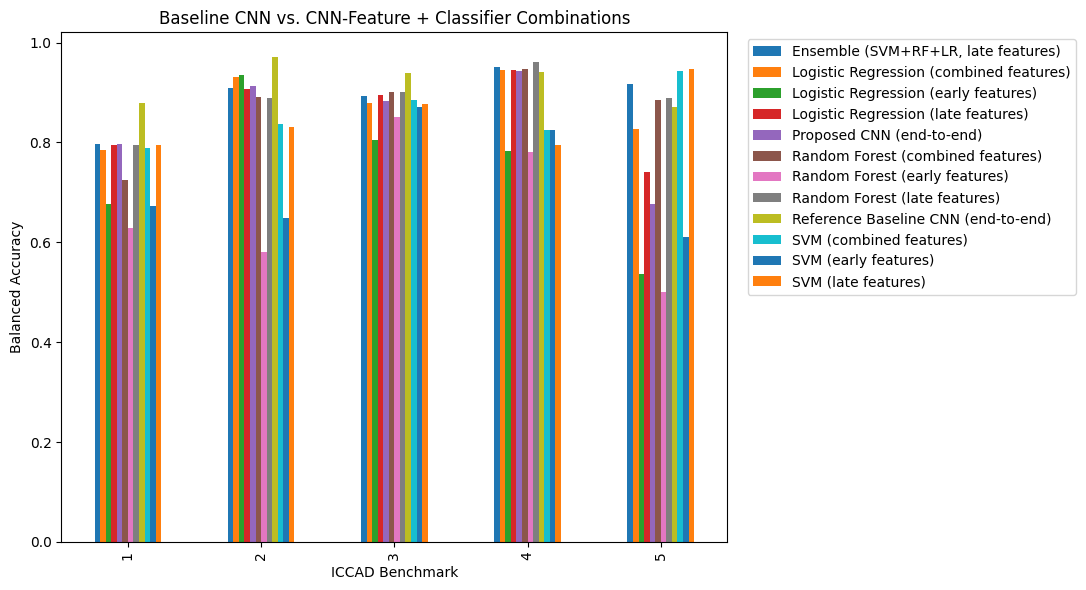

In [16]:
# 12. Plot 1: balanced accuracy comparison across methods, per benchmark
summary = all_metric_tables["balanced_accuracy"]
fig, ax = plt.subplots(figsize=(11, 6))
summary.drop(columns="Average").T.plot(kind="bar", ax=ax)
ax.set_ylabel("Balanced Accuracy")
ax.set_xlabel("ICCAD Benchmark")
ax.set_title("Baseline CNN vs. CNN-Feature + Classifier Combinations")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("/content/balanced_accuracy_comparison.png", dpi=150)
plt.show()

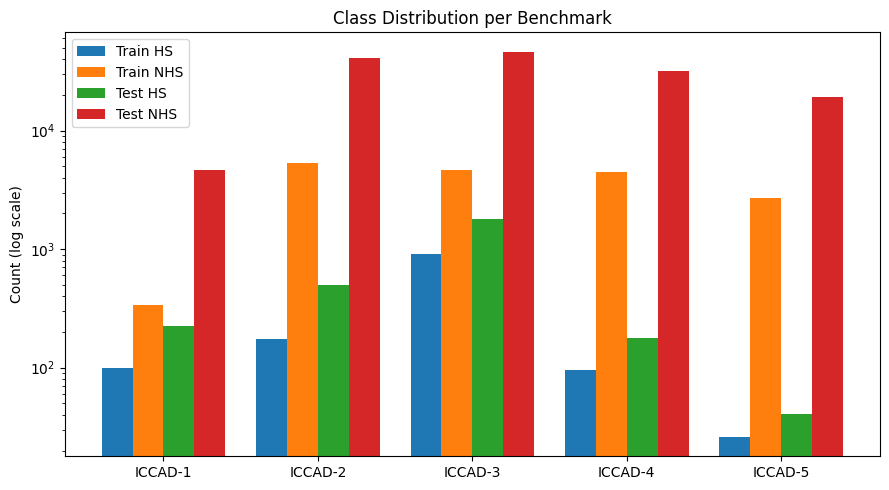

In [17]:
# 13. Plot 2: class distribution per benchmark (imbalance analysis)
dist_data = []
for b in BENCHMARKS:
    tr_f, tr_l = list_files_labels(b, "train")
    te_f, te_l = list_files_labels(b, "test")
    dist_data.append([sum(tr_l), len(tr_l)-sum(tr_l), sum(te_l), len(te_l)-sum(te_l)])

dist_data = np.array(dist_data)
x = np.arange(len(BENCHMARKS))
width = 0.2

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 1.5*width, dist_data[:,0], width, label="Train HS")
ax.bar(x - 0.5*width, dist_data[:,1], width, label="Train NHS")
ax.bar(x + 0.5*width, dist_data[:,2], width, label="Test HS")
ax.bar(x + 1.5*width, dist_data[:,3], width, label="Test NHS")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([f"ICCAD-{b}" for b in BENCHMARKS])
ax.set_ylabel("Count (log scale)")
ax.set_title("Class Distribution per Benchmark")
ax.legend()
plt.tight_layout()
plt.savefig("/content/class_distribution.png", dpi=150)
plt.show()

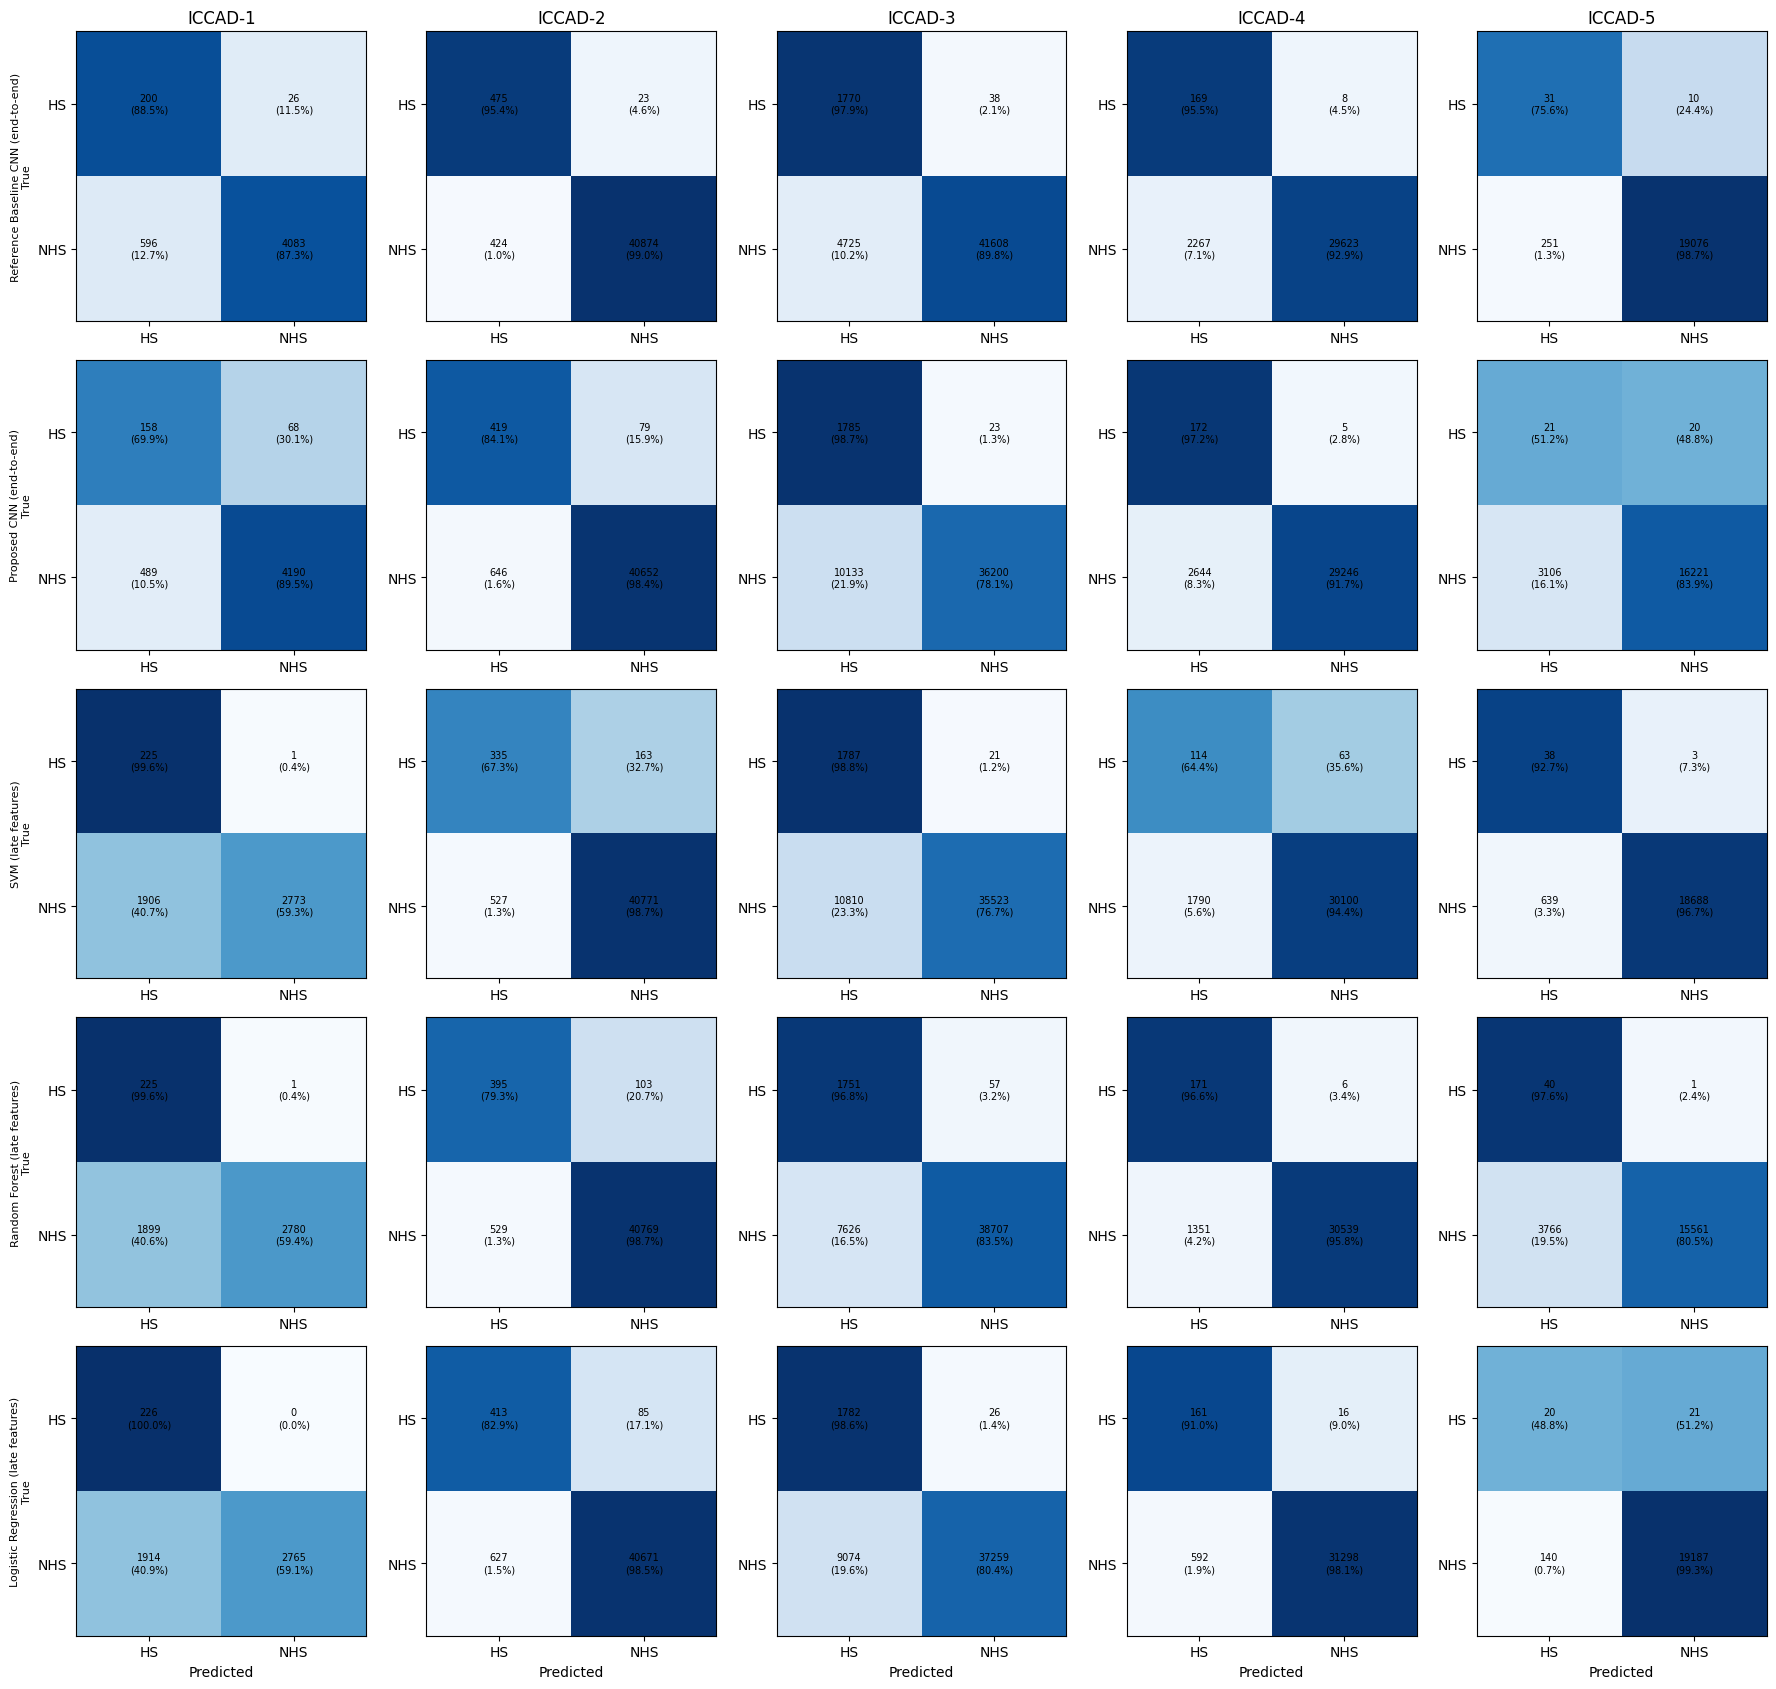

In [18]:
# 14. Plot 3: confusion matrix heatmaps -- normalized by true class (row %) so the
# NHS-heavy cells (TN) don't visually drown out the rare HS cells (TP/FN); raw counts
# are still annotated in each cell.
methods_to_show = ["Reference Baseline CNN (end-to-end)", "Proposed CNN (end-to-end)",
                    "SVM (late features)", "Random Forest (late features)",
                    "Logistic Regression (late features)"]

fig, axes = plt.subplots(len(methods_to_show), 5, figsize=(18, 17))

for row, method in enumerate(methods_to_show):
    for col, b in enumerate(BENCHMARKS):
        rec = next(r for r in results if r["benchmark"] == b and r["method"] == method)
        cm = np.array(rec["confusion_matrix"])            # [[TP, FN], [FP, TN]]
        cm_pct = cm / cm.sum(axis=1, keepdims=True)        # row-normalized (% of true class)
        ax = axes[row, col]
        ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=1)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{cm[i, j]}\n({cm_pct[i, j]*100:.1f}%)",
                        ha="center", va="center", fontsize=7)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["HS", "NHS"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["HS", "NHS"])
        if col == 0:
            ax.set_ylabel(f"{method}\nTrue", fontsize=8)
        if row == 0:
            ax.set_title(f"ICCAD-{b}")
        if row == len(methods_to_show) - 1:
            ax.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("/content/confusion_matrices.png", dpi=150)
plt.show()

In [19]:
# 16. Timing / parameter-count / feature-dimension summary (for the report's efficiency discussion)
timing_df = pd.DataFrame(timing_info).T
timing_df.index.name = "benchmark"
print(timing_df)
timing_df.to_csv("/content/da2_timing_and_dims.csv")

          reference_baseline_inference_sec_per_img  \
benchmark                                            
1                                         0.001219   
2                                         0.001114   
3                                         0.001078   
4                                          0.00113   
5                                          0.00108   

          proposed_cnn_inference_sec_per_img  \
benchmark                                      
1                                   0.002043   
2                                   0.001263   
3                                   0.001182   
4                                   0.001251   
5                                   0.001358   

                                          feature_dims  \
benchmark                                                
1          {'early': 64, 'late': 128, 'combined': 192}   
2          {'early': 64, 'late': 128, 'combined': 192}   
3          {'early': 64, 'late': 128, 'combined': 19